<a href="https://colab.research.google.com/github/Kevingm96/Redes-Neuronales/blob/main/redes_neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INTRODUCCIÓN A LOS MODELOS DE CALIDAD DEL AIRE BASADOS EN INTELIGENCIA ARTIFICIAL**

## Dirección de Meteorología, Clima y Evaluación Ambiental Atmosférica

#### Subdirección de Vigilancia y Evaluación del Ambiente Atmosférico

In [78]:
# **Instalación de paquetes**

!pip install ydata-profiling

# **PROCESAMIENTO Y ANÁLISIS DE LA BASE DE DATOS**

In [79]:
# **Importación de librerias de python**


import matplotlib.pyplot as plt
import numpy as np
import numpy.polynomial.polynomial as poly
import pandas as pd
from ydata_profiling import ProfileReport

plt.rcParams["font.family"] = "monospace"


In [80]:
#from google.colab import drive
#drive.mount('/content/drive')

# Ruta al archivo
ruta = "https://raw.githubusercontent.com/Kevingm96/Redes-Neuronales/refs/heads/main/CDM.csv"

# Leer el CSV
df = pd.read_csv(ruta, sep=";")
# Ver las primeras filas
print(df.head())

# Convertir la columna 'date' a formato datetime
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M')

              date    PM10  temp    HR   PP   VV     DV
0  1/01/2018 00:00  123.20  21.7  79.0  0.0  1.2  224.0
1  1/01/2018 01:00  167.60  21.7  80.0  0.0  0.8  222.0
2  1/01/2018 02:00   76.65  21.4  80.0  0.0  0.5  251.0
3  1/01/2018 03:00   42.41  21.3  80.0  0.0  0.9  228.0
4  1/01/2018 04:00   36.36  21.1  80.0  0.0  0.7  236.0


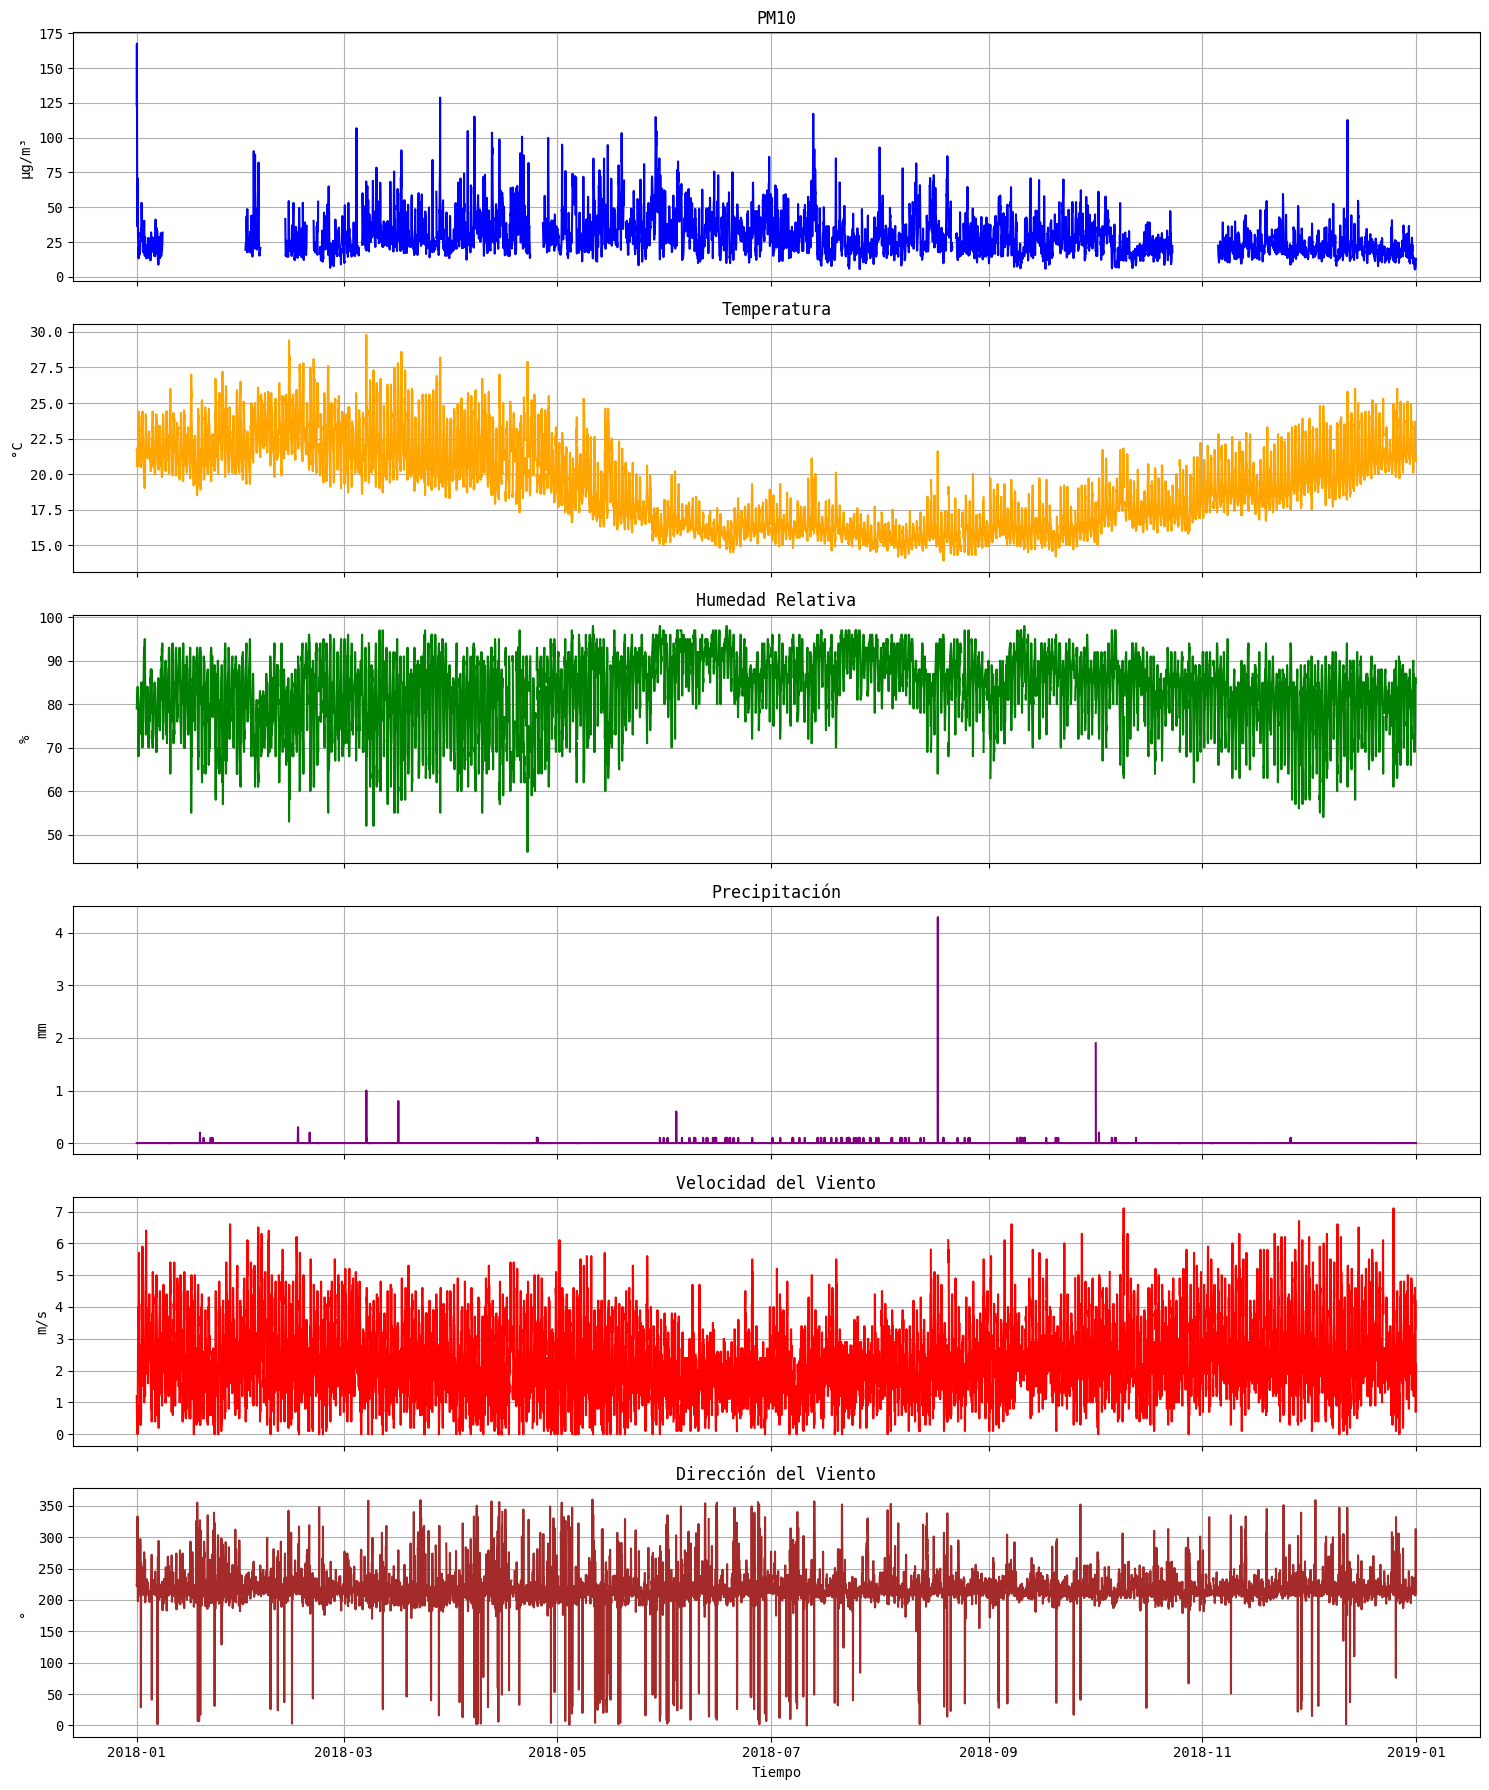

In [81]:
# Crear figura con 6 subplots (uno por variable)
fig, axs = plt.subplots(6, 1, figsize=(15, 18), sharex=True)

# Graficar cada variable
axs[0].plot(df['date'], df['PM10'], color='blue')
axs[0].set_ylabel('µg/m³')
axs[0].set_title('PM10')
axs[0].grid(True)

axs[1].plot(df['date'], df['temp'], color='orange')
axs[1].set_ylabel('°C')
axs[1].set_title('Temperatura')
axs[1].grid(True)

axs[2].plot(df['date'], df['HR'], color='green')
axs[2].set_ylabel('%')
axs[2].set_title('Humedad Relativa')
axs[2].grid(True)

axs[3].plot(df['date'], df['PP'], color='purple')
axs[3].set_ylabel('mm')
axs[3].set_title('Precipitación')
axs[3].grid(True)

axs[4].plot(df['date'], df['VV'], color='red')
axs[4].set_ylabel('m/s')
axs[4].set_title('Velocidad del Viento')
axs[4].grid(True)

axs[5].plot(df['date'], df['DV'], color='brown')
axs[5].set_ylabel('°')
axs[5].set_title('Dirección del Viento')
axs[5].grid(True)

# Etiqueta eje X solo al final
plt.xlabel('Tiempo')

plt.tight_layout()
plt.show()


# reasignando variables y denomainaciones
df = df

# Normalizar nombres de columnas
df.columns = df.columns.str.strip()

# Lista de contaminantes
contaminantes = ["PM10", "temp","HR","PP","VV","DV"]

In [82]:
# -------------------------------
# 3. Convertir contaminantes a numérico
# -------------------------------
for col in contaminantes:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce", downcast="float")

In [83]:
# -------------------------------
# 4. Diagnóstico de valores faltantes
# -------------------------------
print("Valores faltantes por contaminante:\n", df[contaminantes].isna().sum())

Valores faltantes por contaminante:
 PM10    1274
temp      64
HR        67
PP        70
VV        83
DV        75
dtype: int64


In [84]:
# -------------------------------
# 5. Limpieza de filas
# -------------------------------
# Opción A: eliminar filas donde TODOS los contaminantes son NaN
df_lenient = df.dropna(subset=contaminantes, how="all").copy()

# Opción B: eliminar filas donde CUALQUIER contaminante es NaN
df_strict = df.dropna(subset=contaminantes, how="any").copy()

print("\nDimensiones (leniente):", df_lenient.shape)
print("Dimensiones (estricta):", df_strict.shape)


Dimensiones (leniente): (8746, 7)
Dimensiones (estricta): (7420, 7)


In [85]:

# -------------------------------
# 6. Seleccionar columnas finales
# -------------------------------
# -> aquí decides cuál opción usar (lenient o strict)
df_final = df_strict[["date"] + contaminantes]


Ejemplo de datos limpios:
                 date        PM10       temp    HR   PP   VV     DV
0 2018-01-01 00:00:00  123.199997  21.700001  79.0  0.0  1.2  224.0
1 2018-01-01 01:00:00  167.600006  21.700001  80.0  0.0  0.8  222.0
2 2018-01-01 02:00:00   76.650002  21.400000  80.0  0.0  0.5  251.0
3 2018-01-01 03:00:00   42.410000  21.299999  80.0  0.0  0.9  228.0
4 2018-01-01 04:00:00   36.360001  21.100000  80.0  0.0  0.7  236.0


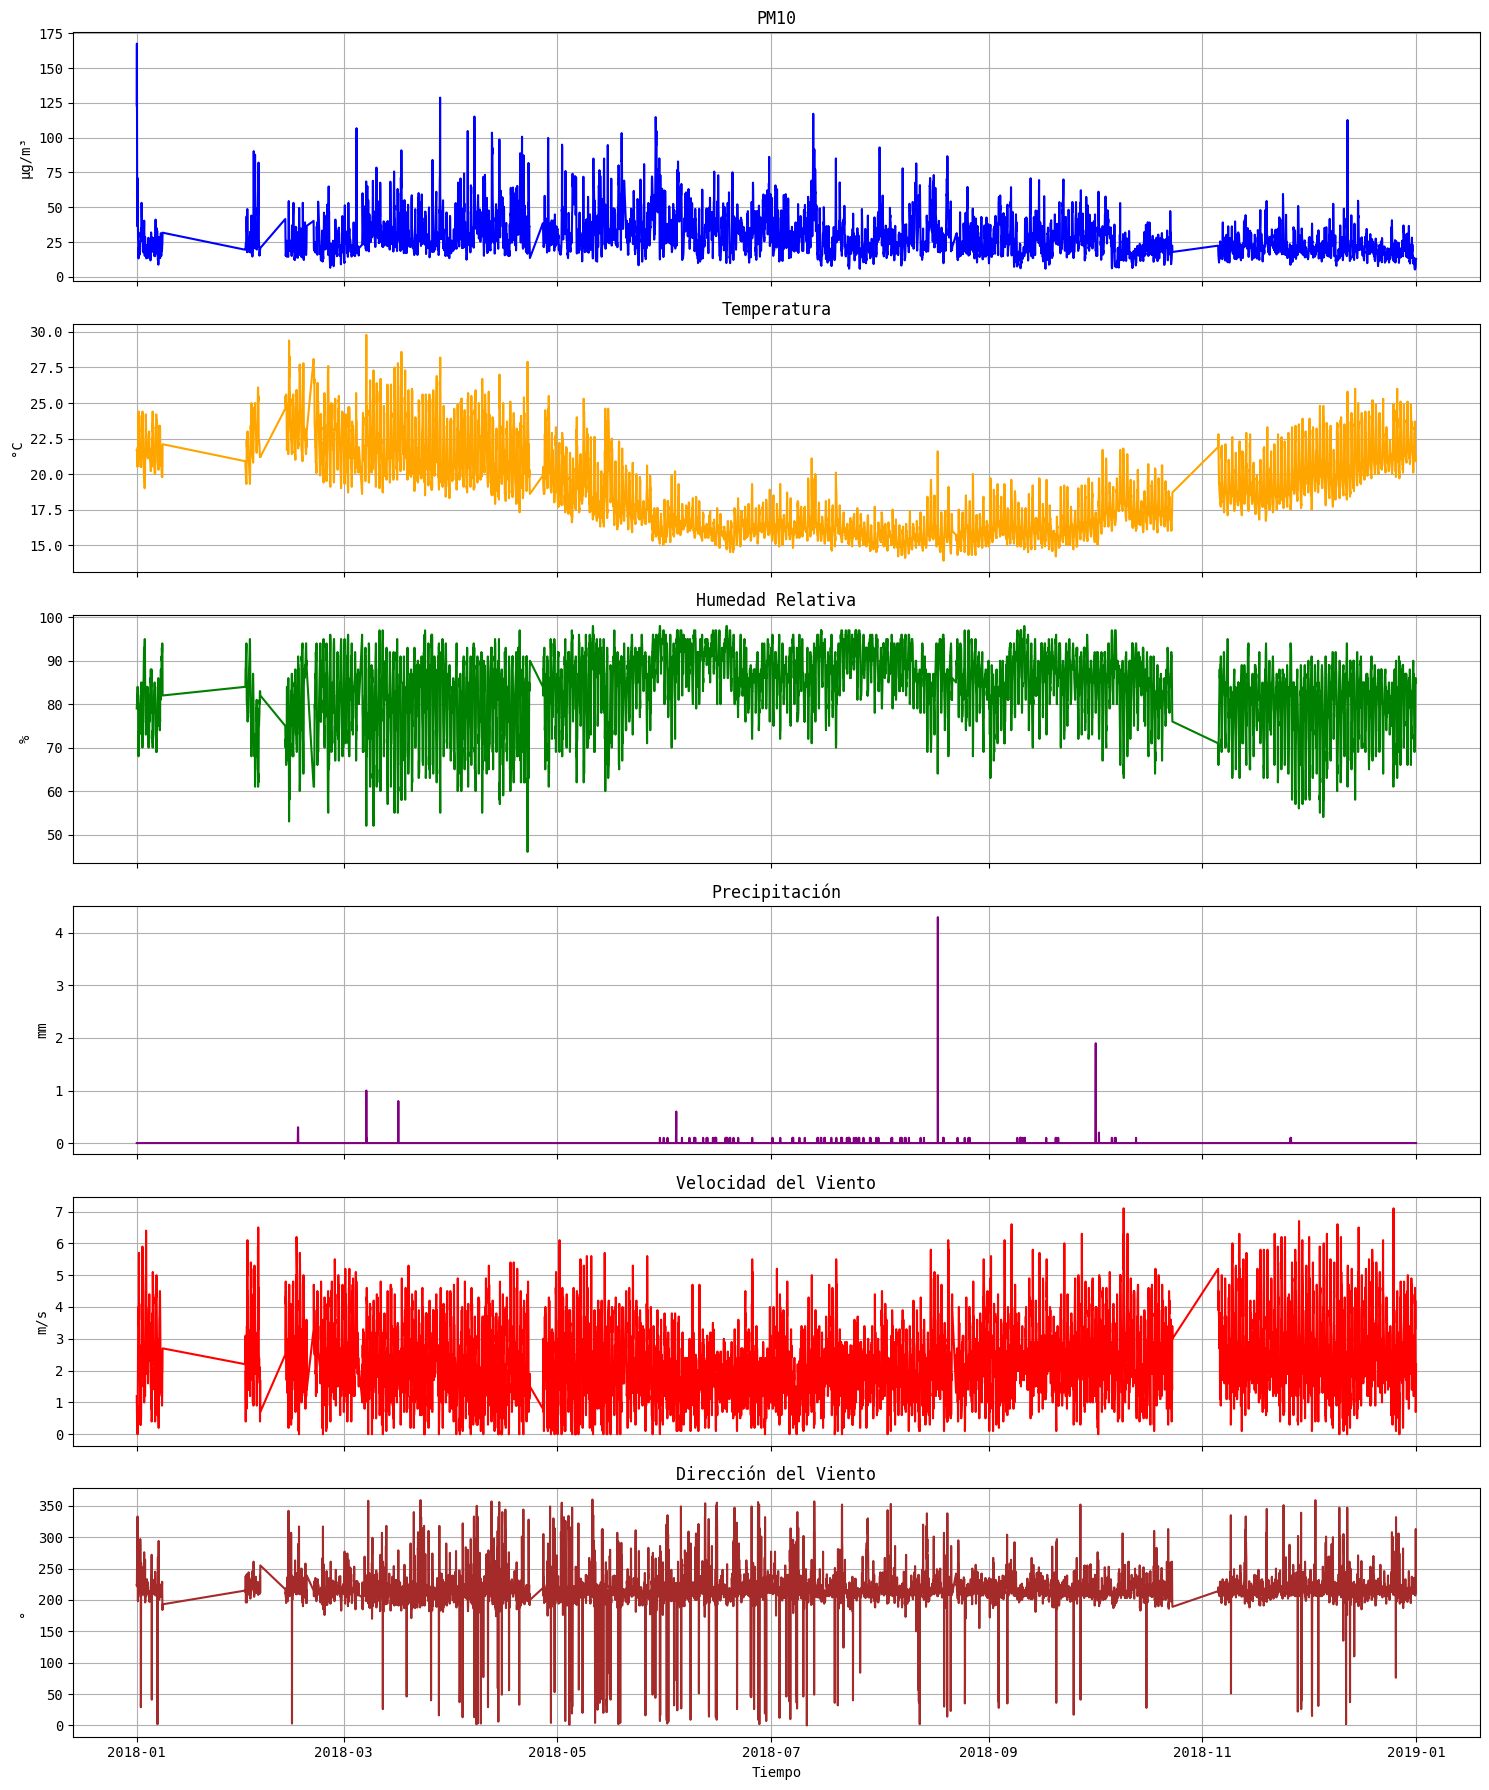

In [86]:
# -------------------------------
# 7. Resultado
# -------------------------------
print("\nEjemplo de datos limpios:")
print(df_final.head())

# Convertir la columna 'date' a formato datetime
df_final['date'] = pd.to_datetime(df_final['date'], format='%d/%m/%Y %H:%M')

# Crear figura con 6 subplots (uno por variable)
fig, axs = plt.subplots(6, 1, figsize=(15, 18), sharex=True)

# Graficar cada variable
axs[0].plot(df_final['date'], df_final['PM10'], color='blue')
axs[0].set_ylabel('µg/m³')
axs[0].set_title('PM10')
axs[0].grid(True)

axs[1].plot(df_final['date'], df_final['temp'], color='orange')
axs[1].set_ylabel('°C')
axs[1].set_title('Temperatura')
axs[1].grid(True)

axs[2].plot(df_final['date'], df_final['HR'], color='green')
axs[2].set_ylabel('%')
axs[2].set_title('Humedad Relativa')
axs[2].grid(True)

axs[3].plot(df_final['date'], df_final['PP'], color='purple')
axs[3].set_ylabel('mm')
axs[3].set_title('Precipitación')
axs[3].grid(True)

axs[4].plot(df_final['date'], df_final['VV'], color='red')
axs[4].set_ylabel('m/s')
axs[4].set_title('Velocidad del Viento')
axs[4].grid(True)

axs[5].plot(df_final['date'], df_final['DV'], color='brown')
axs[5].set_ylabel('°')
axs[5].set_title('Dirección del Viento')
axs[5].grid(True)

# Etiqueta eje X solo al final
plt.xlabel('Tiempo')

plt.tight_layout()
plt.show()

In [87]:
df_final.dtypes

df_final.describe(exclude=[np.datetime64])

ProfileReport(df_final, title="Reporte - CDM", explorative=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 66.07it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]


**IMPLEMENTACIÓN DE UNA RED NEURONAL ARTIFICIAL PARA PRONÓSTICO DE PM10**

**FRAMEWORK**

PyTorch es un framework de aprendizaje profundo de código abierto desarrollado por Meta AI (Facebook) que se distingue por su diseño basado en grafos computacionales dinámicos (define-by-run). A diferencia de los frameworks estáticos, PyTorch construye el grafo de cómputo en tiempo de ejecución, lo que proporciona una gran flexibilidad para implementar arquitecturas no lineales, estructuras de control dinámicas (como bucles y condicionales dependientes de datos) y técnicas de depuración en línea. Esta característica lo convierte en una herramienta idónea tanto para la investigación en prototipado rápido de modelos como para la experimentación avanzada con arquitecturas neuronales complejas. Además, PyTorch integra un motor de autograd altamente optimizado que permite el cálculo automático de gradientes a través de operaciones tensores arbitrarias, soporta ejecución en CPU y GPU mediante CUDA/cuDNN, y se integra con bibliotecas de alto nivel como TorchVision, TorchText y TorchAudio. Su compatibilidad con el ecosistema ONNX y TorchScript facilita la transición desde la fase de investigación hasta la producción en entornos distribuidos o de inferencia optimizada.

https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html

La Red Neuronal Artificial utilizará como variables de entrada el PM10, la Temperatura y la Humedad Relativa, con el objetivo de predecir la concentración de PM10 en la hora siguiente.
"""

In [88]:

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [89]:
#Para iniciar el aprendisaje del modelo, inicialmente la base de datos se dividara  en conjuntos de **train, test y valid**."""

df_final["next_PM10"] = df_final["PM10"].shift(-1)
df_final = df_final.dropna()
df_final


train_size = int(len(df_final) * 0.7)
val_size = int(len(df_final) * 0.15)
test_size = len(df_final) - train_size - val_size

train_data = df_final[["PM10", "temp", "HR"]].iloc[:train_size]
train_label = df_final["next_PM10"].iloc[:train_size]

val_data = df_final[["PM10", "temp", "HR"]].iloc[
    train_size : train_size + val_size
]
val_label = df_final["next_PM10"].iloc[train_size : train_size + val_size]


test_data = df_final[["PM10", "temp", "HR"]].iloc[
    train_size + val_size :
]
test_label = df_final["next_PM10"].iloc[train_size + val_size :]


In [90]:
#Estandarización de la base de datos.

mean = train_data.mean()
std = train_data.std()

train_data_standarized = (train_data - mean) / std
val_data_standarized = (val_data - mean) / std
test_data_standarized = (test_data - mean) / std



In [91]:
## Pytorch proporciona la clase `Dataset` para cargar y manipular los datos. En este caso, crearemos una clase `WeatherDataset` que hereda de la clase `Dataset` y que tomará como entrada los datos y las etiquetas. Para este caso, las entradas serán la PM10, la humedad y temperatura, y las etiquetas serán de concentración de PM10 de la hora siguiente."""

class WeatherDataset(torch.utils.data.Dataset):
    def __init__(self, data_standarized, next_temp):
        self.input = data_standarized[["PM10", "temp", "HR"]].values
        self.output = next_temp.values

    def __len__(self):
        return self.input.shape[0]

    def __getitem__(self, idx):
        return self.input[idx], self.output[idx]


In [92]:
#Luego de definir la clase `WeatherDataset`, crearemos tres instancias de esta clase: una para el conjunto de entrenamiento, una para el conjunto de validación y una para el conjunto de prueba.
#Seguidamente, crearemos tres instancias de la clase `DataLoader` que nos permitirán cargar los datos en lotes durante el entrenamiento del modelo."""

train_dataset = WeatherDataset(train_data_standarized, train_label)

val_dataset = WeatherDataset(val_data_standarized, val_label)

test_dataset = WeatherDataset(test_data_standarized, test_label)

train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=20, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=20, shuffle=False)


In [93]:
# IMPLEMENTACIÓN DE LA RED NEURONAL ARTIFICIAL

# Una vez que hemos separado los datos, es necesario definir la arquitectura el modelo. En este caso, crearemos una clase `ANN` que hereda de la clase `Module` y que definirá la arquitectura de la red neuronal. La red neuronal consistirá en una capa densa que tomará como entrada el PM10, la temperatura y la humedad y producirá como salida PM10.

# La definicion de modelos en Pytorch es muy sencilla, solo necesitamos definir las capas que componen la red neuronal en el método `__init__` y definir la forma en que se propagan los datos a través de la red en el método `forward`.


class WeatherModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [94]:
"""**ENTRENAMIENTO DEL MODELO**

La etapa de entrenamiento constituye uno de los componentes más complejos del flujo de trabajo, dado que PyTorch proporciona una interfaz de bajo nivel que exige al desarrollador definir explícitamente el procedimiento de optimización. Esta característica resulta ventajosa para usuarios avanzados, pues permite diseñar y experimentar con distintos esquemas de actualización de parámetros, funciones de pérdida y estrategias de regularización. No obstante, para usuarios con menor experiencia, la necesidad de comprender en detalle los fundamentos del descenso de gradiente, la propagación hacia atrás y la interacción entre el optimizador y la función de costo puede representar una barrera significativa en la implementación de modelos robustos.
"""

# instanciamos el modelo
model = WeatherModel()

# instanciamos la función de pérdida
criterion = nn.MSELoss()

# instanciamos el optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# entrenamos el modelo
epochs = 140
train_losses = []
val_losses = []

for epoch in range(epochs):
    epoch_loss = []
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()

        # forward pass
        output = model(data)
        loss = criterion(output, target.unsqueeze(1))
        epoch_loss.append(loss.item() * data.size(0))

        # backward pass
        loss.backward()
        optimizer.step()

    model.eval()
    val_loss = []
    for data, target in val_loader:
        output = model(data)
        loss = criterion(output, target.unsqueeze(1))
        val_loss.append(loss.item() * data.size(0))

    # imprimimos la pérdida del epoch
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1}/{epochs} - loss: {sum(epoch_loss) / len(train_dataset)} - val_loss: {sum(val_loss) / len(val_dataset)}"
        )
    train_losses.append(sum(epoch_loss) / len(train_dataset))
    val_losses.append(sum(val_loss) / len(val_dataset))


Epoch 1/140 - loss: 291.27608491312486 - val_loss: 46.21601791176007
Epoch 20/140 - loss: 67.86469486676589 - val_loss: 29.092284363808393
Epoch 40/140 - loss: 67.5978571111105 - val_loss: 30.721554725290204
Epoch 60/140 - loss: 67.28627223663653 - val_loss: 27.672796813704128
Epoch 80/140 - loss: 67.56159407367555 - val_loss: 29.481735684031204
Epoch 100/140 - loss: 66.60581313790142 - val_loss: 27.51128763775174
Epoch 120/140 - loss: 66.00770189361307 - val_loss: 30.727948586717783
Epoch 140/140 - loss: 66.65380842406098 - val_loss: 35.023170162447926


Test Loss: 36.135852601412594


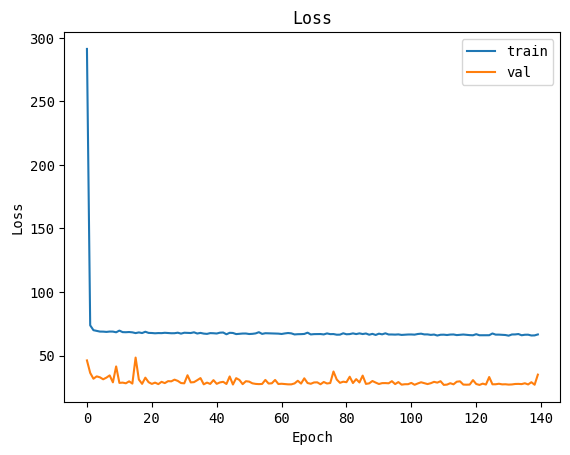

In [95]:

# Commented out IPython magic to ensure Python compatibility.
# %matplotlib inline
fig, ax = plt.subplots()
ax.plot(train_losses, label="train")
ax.plot(val_losses, label="val")
ax.legend()
ax.set_title("Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

model.eval()
test_losses = []
predictions = []

with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        loss = criterion(output, target.unsqueeze(1))
        test_losses.append(loss.item() * len(data))
        predictions.append(output)
predictions = np.concatenate(predictions).ravel()
print(f"Test Loss: {sum(test_losses) / len(test_dataset)}")

MAE: 4.602
MSE: 36.136
RMSE: 6.011
R²: 0.501
r de Pearson: 0.804
p-valor: 5.3708e-253
Bias: 3.131


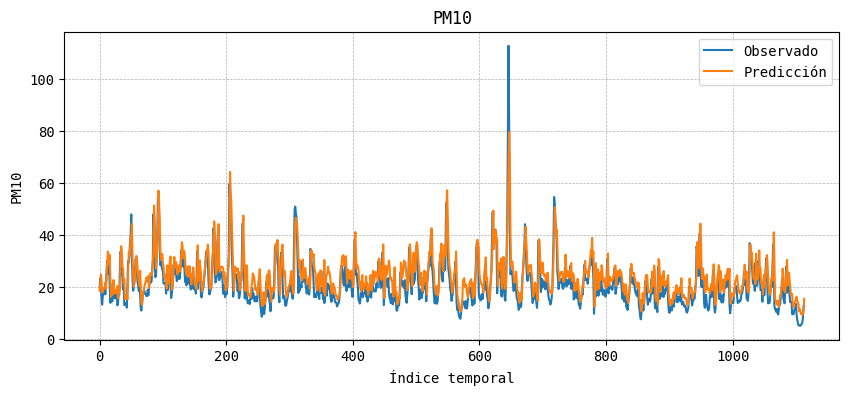

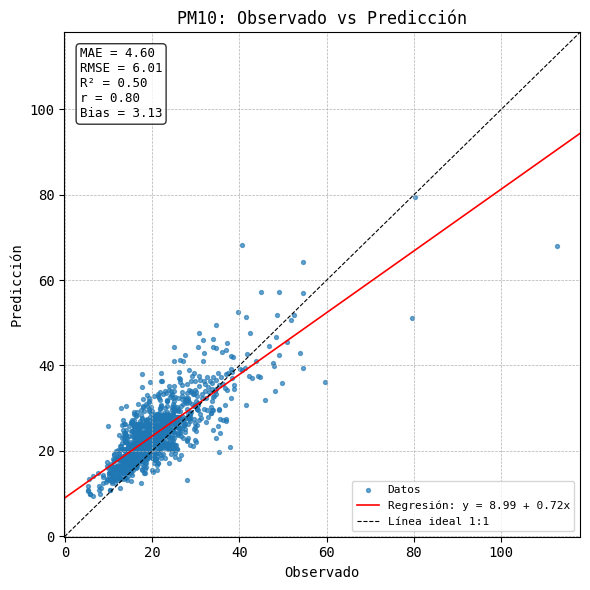

In [96]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.polynomial import polynomial as poly
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from scipy.stats import pearsonr


# ============================================================
# PREPARACIÓN DE DATOS
# ============================================================

# Convertimos a arrays de NumPy y aseguramos que sean unidimensionales
y_true = np.asarray(test_label.values).reshape(-1)
y_pred = np.asarray(predictions).reshape(-1)

# Verificamos que tengan la misma cantidad de datos
if len(y_true) != len(y_pred):
    raise ValueError("y_true y y_pred deben tener la misma longitud.")


# ============================================================
# MÉTRICAS ESTADÍSTICAS
# ============================================================

# Error absoluto medio
mae = mean_absolute_error(y_true, y_pred)

# Error cuadrático medio
mse = mean_squared_error(y_true, y_pred)

# Raíz del error cuadrático medio
rmse = np.sqrt(mse)

# Coeficiente de determinación
r2 = r2_score(y_true, y_pred)

# Correlación de Pearson
r, p_value = pearsonr(y_true, y_pred)

# Sesgo medio: predicción - observado
bias = np.mean(y_pred - y_true)

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")
print(f"r de Pearson: {r:.3f}")
print(f"p-valor: {p_value:.4e}")
print(f"Bias: {bias:.3f}")


# ============================================================
# GRÁFICO TEMPORAL
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(y_true, label="Observado")
ax.plot(y_pred, label="Predicción")

ax.legend()
ax.set_title("PM10")
ax.set_xlabel("Índice temporal")
ax.set_ylabel("PM10")

ax.grid(ls="--", lw=0.5)


# ============================================================
# REGRESIÓN LINEAL
# ============================================================

coefs = poly.polyfit(y_true, y_pred, 1)
ffit = poly.Polynomial(coefs)


# ============================================================
# GRÁFICO TRUE VS PRED
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    y_true,
    y_pred,
    s=8,
    alpha=0.65,
    label="Datos"
)

# Límites calculados a partir de los datos
min_value = min(y_true.min(), y_pred.min())
max_value = max(y_true.max(), y_pred.max())

# Margen visual
margin = 0.05 * (max_value - min_value)

xmin = min_value - margin
xmax = max_value + margin

# Línea de regresión
x = np.linspace(xmin, xmax, 100)
y = ffit(x)

ax.plot(
    x,
    y,
    color="red",
    lw=1.2,
    label=f"Regresión: y = {coefs[0]:.2f} + {coefs[1]:.2f}x"
)

# Línea ideal 1:1
ax.plot(
    [xmin, xmax],
    [xmin, xmax],
    ls="--",
    lw=0.8,
    color="black",
    label="Línea ideal 1:1"
)

# Cuadro de métricas
metrics_text = (
    f"MAE = {mae:.2f}\n"
    f"RMSE = {rmse:.2f}\n"
    f"R² = {r2:.2f}\n"
    f"r = {r:.2f}\n"
    f"Bias = {bias:.2f}"
)

ax.text(
    0.03,
    0.97,
    metrics_text,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.8
    )
)

ax.set_xlabel("Observado")
ax.set_ylabel("Predicción")
ax.set_title("PM10: Observado vs Predicción")

ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)

ax.grid(ls="--", lw=0.5)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

"""# **IMPLEMENTACIÓN DE UNA RED NEURONAL ARTIFICIAL PARA PRONÓSTICO DEL INDICE ULTRAVIOLETA SOLAR**

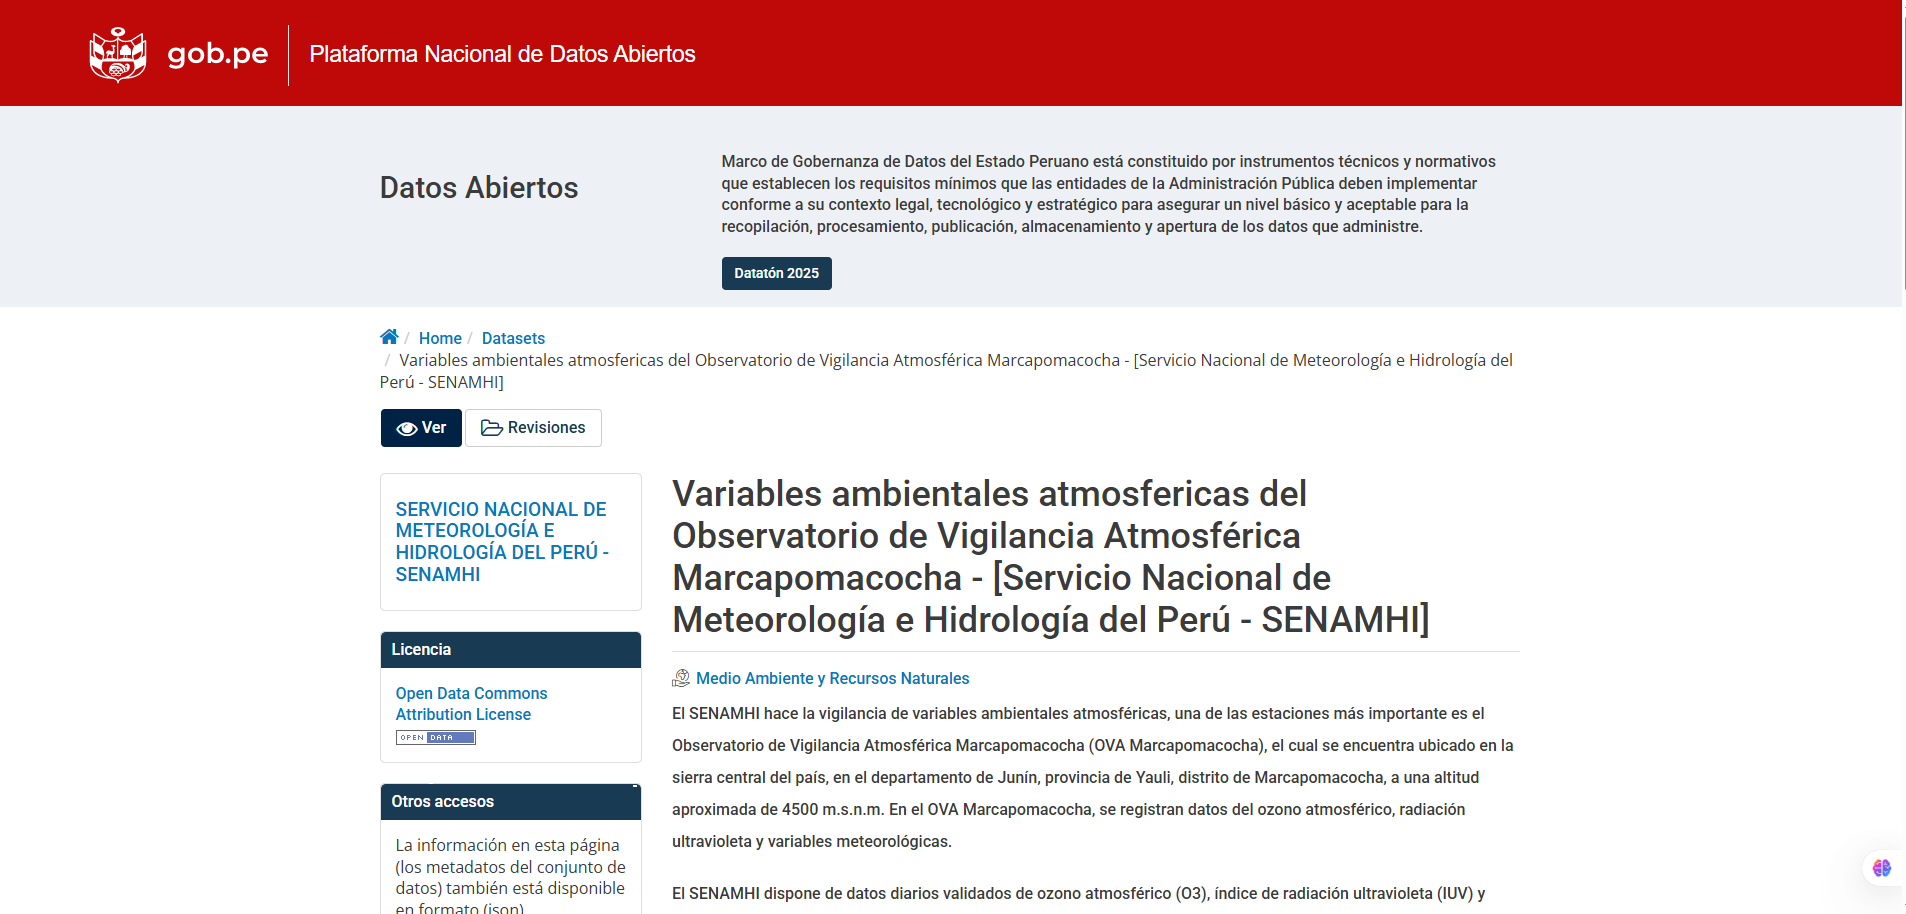

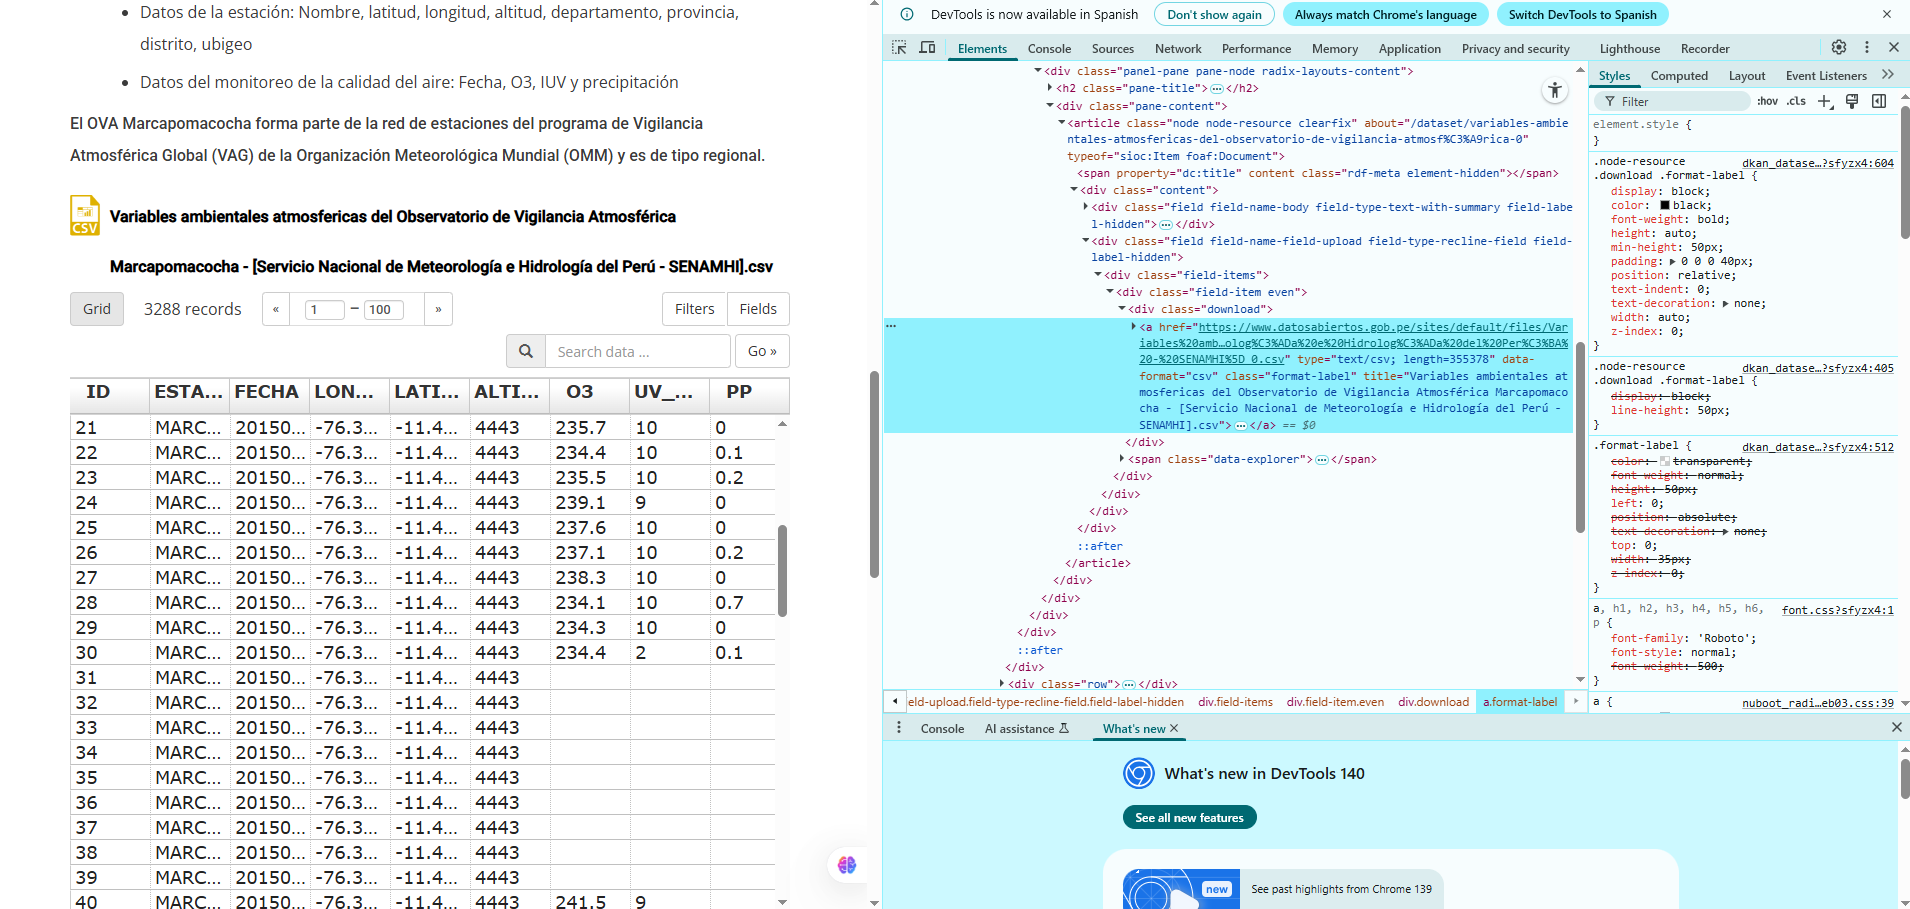

https://www.datosabiertos.gob.pe/dataset/variables-ambientales-atmosfericas-del-observatorio-de-vigilancia-atmosf%C3%A9rica-marcapomacocha
"""

In [97]:

import requests
import pandas as pd
from io import StringIO

In [98]:

url = "https://www.datosabiertos.gob.pe/sites/default/files/Variables%20ambientales%20atmosfericas%20del%20Observatorio%20de%20Vigilancia%20Atmosf%C3%A9rica%20Marcapomacocha%20-%20%5BServicio%20Nacional%20de%20Meteorolog%C3%ADa%20e%20Hidrolog%C3%ADa%20del%20Per%C3%BA%20-%20SENAMHI%5D_0.csv"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/122.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers)

if response.status_code == 200:
    df = pd.read_csv(StringIO(response.text))
    print(df.head())
else:
    print(f"Error al descargar. Status code: {response.status_code}")

df['FECHA'] = pd.to_datetime(df['FECHA'], format='%Y%m%d').dt.strftime('%Y/%m/%d')

print(df['FECHA'])

df['FECHA'] = pd.to_datetime(df['FECHA'], format='%Y/%m/%d')





   ID        ESTACION     FECHA  LONGITUD   LATITUD  ALTITUD  O3  UV_MAX  PP  \
0   1  MARCAPOMACOCHA  20150601 -76.32508 -11.40443     4443 NaN     8.0 NaN   
1   2  MARCAPOMACOCHA  20150602 -76.32508 -11.40443     4443 NaN    10.0 NaN   
2   3  MARCAPOMACOCHA  20150603 -76.32508 -11.40443     4443 NaN    11.0 NaN   
3   4  MARCAPOMACOCHA  20150604 -76.32508 -11.40443     4443 NaN     9.0 NaN   
4   5  MARCAPOMACOCHA  20150605 -76.32508 -11.40443     4443 NaN     7.0 NaN   

  DEPARTAMENTO PROVINCIA        DISTRITO  UBIGEO  FECHA_CORTE  
0        JUNIN     YAULI  MARCAPOMACOCHA  120804     20240531  
1        JUNIN     YAULI  MARCAPOMACOCHA  120804     20240531  
2        JUNIN     YAULI  MARCAPOMACOCHA  120804     20240531  
3        JUNIN     YAULI  MARCAPOMACOCHA  120804     20240531  
4        JUNIN     YAULI  MARCAPOMACOCHA  120804     20240531  
0       2015/06/01
1       2015/06/02
2       2015/06/03
3       2015/06/04
4       2015/06/05
           ...    
3283    2024/05/27
32

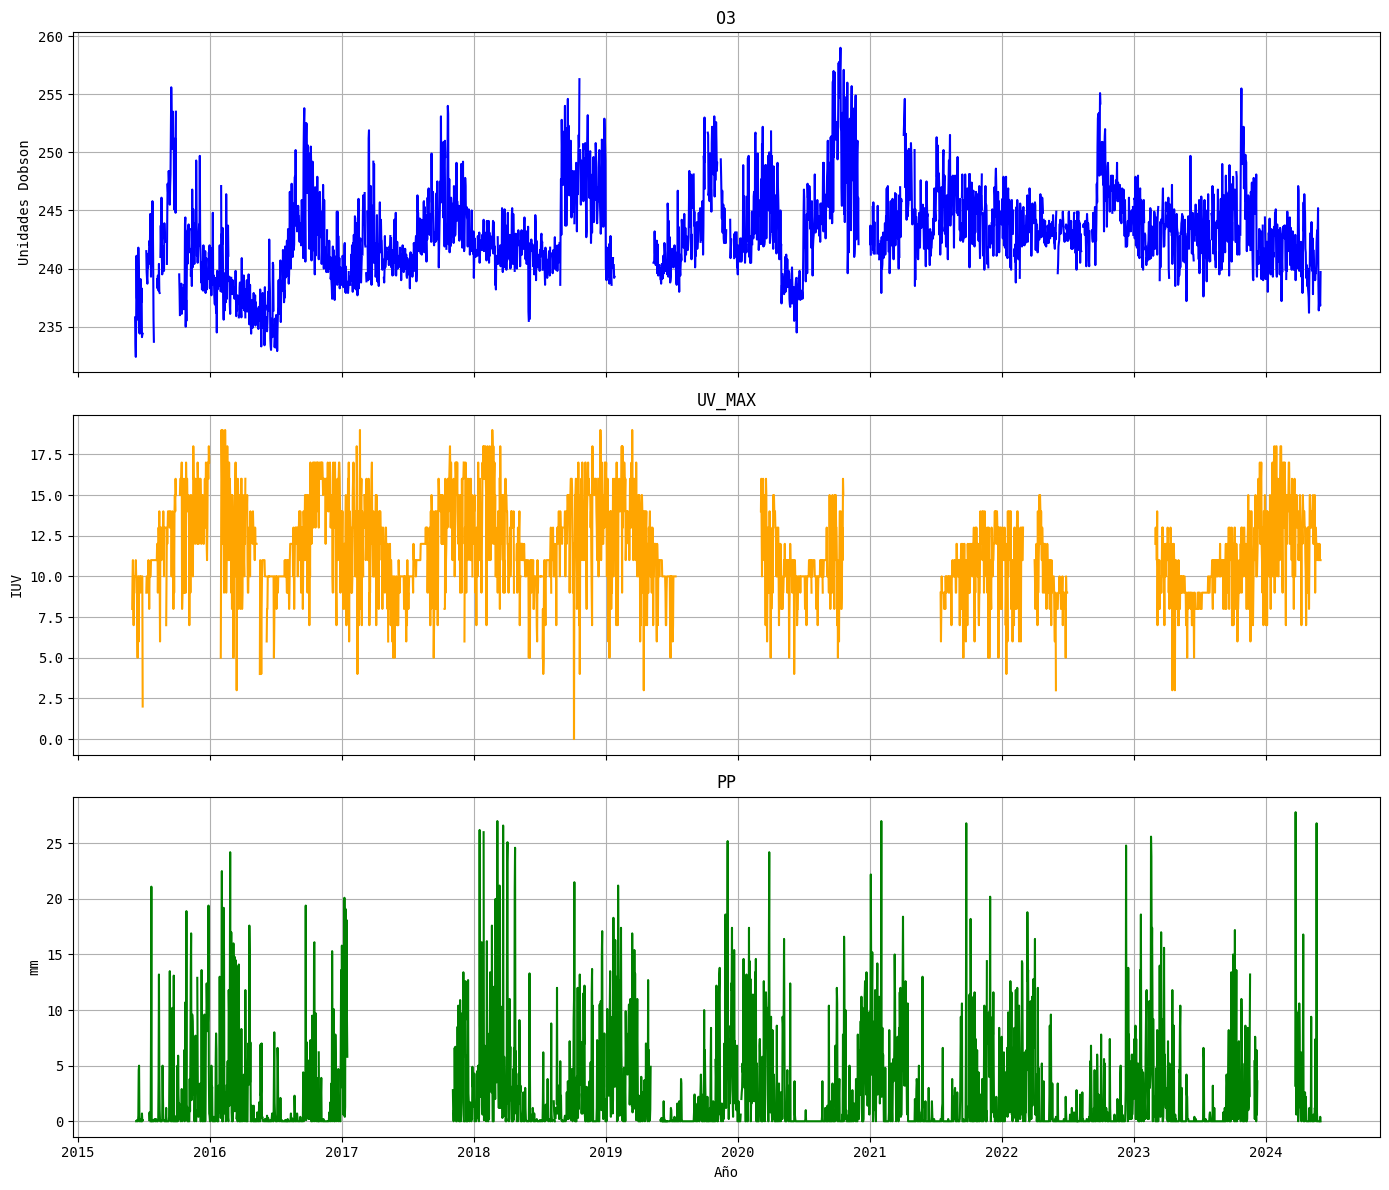

In [99]:
fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# O3 (unidades Dobson)
axs[0].plot(df['FECHA'], df['O3'], color='blue')
axs[0].set_ylabel('Unidades Dobson')
axs[0].set_title('O3')
axs[0].grid(True)

# UV_MAX (IUV, adimensional)
axs[1].plot(df['FECHA'], df['UV_MAX'], color='orange')
axs[1].set_ylabel('IUV')
axs[1].set_title('UV_MAX')
axs[1].grid(True)

# PP (milímetros)
axs[2].plot(df['FECHA'], df['PP'], color='green')
axs[2].set_ylabel('mm')
axs[2].set_title('PP')
axs[2].grid(True)

# Formatear eje x para mostrar años
plt.xlabel('Año')

plt.tight_layout()
plt.show()

df = df
# Normalizar nombres de columnas
df.columns = df.columns.str.strip()
# Lista de variables
variables = ["O3", "PP", "UV_MAX"]

In [100]:
# -------------------------------
# 3. Convertir variables a numérico
# -------------------------------
for col in variables:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce", downcast="float")


In [101]:
# -------------------------------
# 4. Diagnóstico de valores faltantes
# -------------------------------
print("Valores faltantes por variables:\n", df[variables].isna().sum())


Valores faltantes por variables:
 O3        353
PP        481
UV_MAX    865
dtype: int64


In [102]:
# -------------------------------
# 5. Limpieza de filas
# -------------------------------
# Opción A: eliminar filas donde TODOS los variables son NaN
df_lenient = df.dropna(subset=variables, how="all").copy()

# Opción B: eliminar filas donde CUALQUIER variables es NaN
df_strict = df.dropna(subset=variables, how="any").copy()

print("\nDimensiones (leniente):", df_lenient.shape)
print("Dimensiones (estricta):", df_strict.shape)


Dimensiones (leniente): (3279, 14)
Dimensiones (estricta): (1783, 14)


In [103]:
# -------------------------------
# 6. Seleccionar columnas finales
# -------------------------------
# -> aquí decides cuál opción usar (lenient o strict)
df_final = df_strict[["FECHA"] + variables]

In [104]:
# -------------------------------
# 7. Resultado
# -------------------------------
print("\nEjemplo de datos limpios:")
print(df_final.head())


df.describe(exclude=[np.datetime64])

ProfileReport(df, title="Reporte - OBSERVATORIO DE VIGILANCIA ATMOSFÉRICA MARCAPOMACOCHA", explorative=True)



Ejemplo de datos limpios:
        FECHA          O3   PP  UV_MAX
11 2015-06-12  235.699997  0.0    10.0
12 2015-06-13  241.100006  0.0     9.0
13 2015-06-14  237.500000  0.1     9.0
14 2015-06-15  237.100006  0.1     7.0
15 2015-06-16  237.800003  0.0     5.0


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 42.90it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [159]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [160]:
df["next_UV_MAX"] = df["UV_MAX"].shift(-1)
df = df.dropna()
df


/tmp/ipykernel_1160/1128069190.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["next_UV_MAX"] = df["UV_MAX"].shift(-1)


,ID,ESTACION,FECHA,LONGITUD,LATITUD,ALTITUD,O3,UV_MAX,PP,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO,FECHA_CORTE,next_UV_MAX
11,12,MARCAPOMACOCHA,2015-06-12,-76.32508,-11.40443,4443,235.699997,10.0,0.0,JUNIN,YAULI,MARCAPOMACOCHA,120804,20240531,9.0
12,13,MARCAPOMACOCHA,2015-06-13,-76.32508,-11.40443,4443,241.100006,9.0,0.0,JUNIN,YAULI,MARCAPOMACOCHA,120804,20240531,9.0
13,14,MARCAPOMACOCHA,2015-06-14,-76.32508,-11.40443,4443,237.500000,9.0,0.1,JUNIN,YAULI,MARCAPOMACOCHA,120804,20240531,7.0
14,15,MARCAPOMACOCHA,2015-06-15,-76.32508,-11.40443,4443,237.100006,7.0,0.1,JUNIN,YAULI,MARCAPOMACOCHA,120804,20240531,5.0
15,16,MARCAPOMACOCHA,2015-06-16,-76.32508,-11.40443,4443,237.800003,5.0,0.0,JUNIN,YAULI,MARCAPOMACOCHA,120804,20240531,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3277,3257,MARCAPOMACOCHA,2024-05-21,-76.32508,-11.40443,4443,243.000000,11.0,0.8,JUNIN,YAULI,MARCAPOMACOCHA,120804,20240531,12.0
3278,3257,MARCAPOMACOCHA,2024-05-22,-76.32508,-11.40443,4443,243.300003,12.0,0.0,JUNIN,YAULI,MARCAPOMACOCHA,120804,20240531,12.0
3279,3257,MARCAPOMACOCHA,2024-05-23,-76.32508,-11.40443,4443,243.100006,12.0,0.0,JUNIN,YAULI,MARCAPOMACOCHA,120804,20240531,12.0
3280,3257,MARCAPOMACOCHA,2024-05-24,-76.32508,-11.40443,4443,245.199997,12.0,0.0,JUNIN,YAULI,MARCAPOMACOCHA,120804,20240531,11.0


In [161]:
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_data = df[["O3", "PP", "UV_MAX"]].iloc[:train_size]
train_label = df["next_UV_MAX"].iloc[:train_size]

val_data = df[["O3", "PP", "UV_MAX"]].iloc[
    train_size : train_size + val_size
]
val_label = df["next_UV_MAX"].iloc[train_size : train_size + val_size]

test_data = df[["O3", "PP", "UV_MAX"]].iloc[
    train_size + val_size :
]
test_label = df["next_UV_MAX"].iloc[train_size + val_size :]


In [162]:
# estandarización

mean = train_data.mean()
std = train_data.std()

train_data_standarized = (train_data - mean) / std
val_data_standarized = (val_data - mean) / std
test_data_standarized = (test_data - mean) / std

In [163]:
class WeatherDataset(torch.utils.data.Dataset):
    def __init__(self, data_standarized, next_temp):
        self.input = data_standarized[["O3", "PP", "UV_MAX"]].values
        self.output = next_temp.values

    def __len__(self):
        return self.input.shape[0]

    def __getitem__(self, idx):
        return self.input[idx], self.output[idx]

train_dataset = WeatherDataset(train_data_standarized, train_label)

val_dataset = WeatherDataset(val_data_standarized, val_label)

test_dataset = WeatherDataset(test_data_standarized, test_label)

train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=20, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=20, shuffle=False)


In [164]:
class WeatherModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [165]:
# instanciamos el modelo
model = WeatherModel()

# instanciamos la función de pérdida
criterion = nn.MSELoss()

# instanciamos el optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# entrenamos el modelo
epochs = 40
train_losses = []
val_losses = []

for epoch in range(epochs):
    epoch_loss = []
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()

        # forward pass
        output = model(data)
        loss = criterion(output, target.unsqueeze(1))
        epoch_loss.append(loss.item() * data.size(0))

        # backward pass
        loss.backward()
        optimizer.step()

    model.eval()
    val_loss = []
    for data, target in val_loader:
        output = model(data)
        loss = criterion(output, target.unsqueeze(1))
        val_loss.append(loss.item() * data.size(0))

    # imprimimos la pérdida del epoch
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1}/{epochs} - loss: {sum(epoch_loss) / len(train_dataset)} - val_loss: {sum(val_loss) / len(val_dataset)}"
        )
    train_losses.append(sum(epoch_loss) / len(train_dataset))
    val_losses.append(sum(val_loss) / len(val_dataset))


Epoch 1/40 - loss: 102.55592927574916 - val_loss: 12.954887637655244
Epoch 20/40 - loss: 5.181357139086451 - val_loss: 5.382265746138478
Epoch 40/40 - loss: 4.999475581027555 - val_loss: 5.082981843074769


Test Loss: 3.0718069584532217


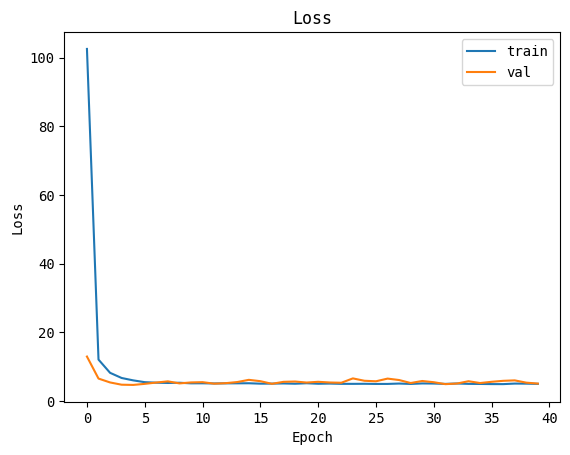

In [166]:
# Commented out IPython magic to ensure Python compatibility.
# %matplotlib inline
fig, ax = plt.subplots()
ax.plot(train_losses, label="train")
ax.plot(val_losses, label="val")
ax.legend()
ax.set_title("Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

model.eval()
test_losses = []
predictions = []

with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        loss = criterion(output, target.unsqueeze(1))
        test_losses.append(loss.item() * len(data))
        predictions.append(output)
predictions = np.concatenate(predictions).ravel()
print(f"Test Loss: {sum(test_losses) / len(test_dataset)}")


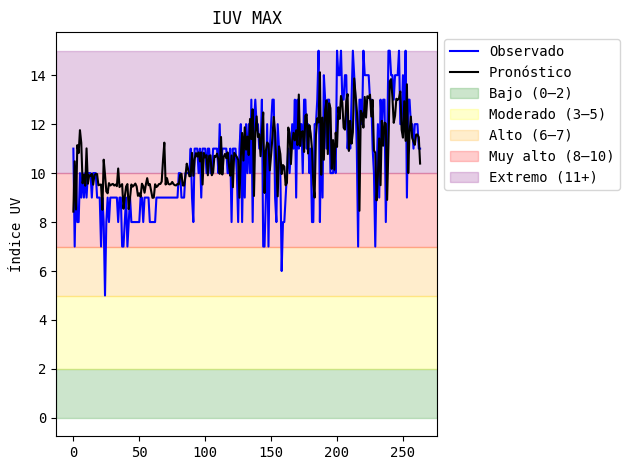

In [167]:
fig, ax = plt.subplots()

# Series
ax.plot(test_label.values,color="blue", label="Observado")
ax.plot(predictions, color="black",label="Pronóstico")

# Rangos OMS
ax.axhspan(0, 2, color="green", alpha=0.2, label="Bajo (0–2)")
ax.axhspan(2, 5, color="yellow", alpha=0.2, label="Moderado (3–5)")
ax.axhspan(5, 7, color="orange", alpha=0.2, label="Alto (6–7)")
ax.axhspan(7, 10, color="red", alpha=0.2, label="Muy alto (8–10)")
ax.axhspan(10, max(max(test_label.values), max(predictions)),
           color="purple", alpha=0.2, label="Extremo (11+)")

# Estilo
ax.set_title("IUV MAX")
ax.set_ylabel("Índice UV")
ax.legend(loc="upper left", bbox_to_anchor=(1,1))  # leyenda fuera si quieres

plt.tight_layout()
plt.show()


MAE: 1.337
MSE: 3.072
RMSE: 1.753
R²: 0.286
r de Pearson: 0.553
p-valor: 1.5531e-22
Bias: 0.258


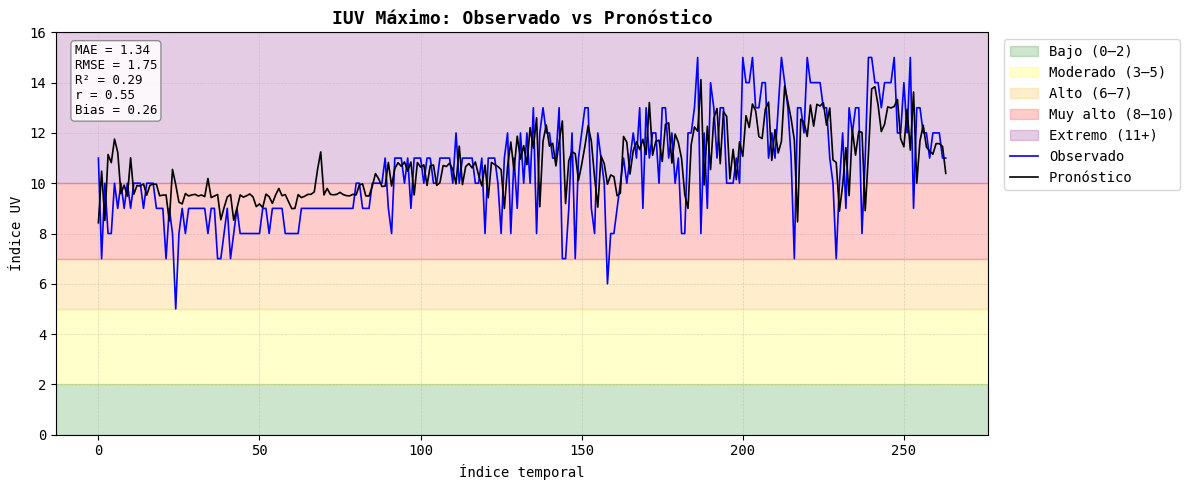

In [168]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from scipy.stats import pearsonr

# ============================================================
# PREPARACIÓN DE DATOS
# ============================================================

y_true = np.asarray(test_label.values).reshape(-1)
y_pred = np.asarray(predictions).reshape(-1)

if len(y_true) != len(y_pred):
    raise ValueError("y_true y y_pred deben tener la misma longitud.")


# ============================================================
# MÉTRICAS ESTADÍSTICAS
# ============================================================

mae = mean_absolute_error(y_true, y_pred)

mse = mean_squared_error(y_true, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_true, y_pred)

# Correlación de Pearson
r, p_value = pearsonr(y_true, y_pred)

# Bias = Predicción - Observado
bias = np.mean(y_pred - y_true)


# Mostrar resultados
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")
print(f"r de Pearson: {r:.3f}")
print(f"p-valor: {p_value:.4e}")
print(f"Bias: {bias:.3f}")


# ============================================================
# GRÁFICO TEMPORAL
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))


# ============================================================
# RANGOS DEL ÍNDICE UV
# ============================================================

ax.axhspan(
    0, 2,
    color="green",
    alpha=0.20,
    label="Bajo (0–2)"
)

ax.axhspan(
    2, 5,
    color="yellow",
    alpha=0.20,
    label="Moderado (3–5)"
)

ax.axhspan(
    5, 7,
    color="orange",
    alpha=0.20,
    label="Alto (6–7)"
)

ax.axhspan(
    7, 10,
    color="red",
    alpha=0.20,
    label="Muy alto (8–10)"
)

# Extremo
max_uv = max(y_true.max(), y_pred.max())

ax.axhspan(
    10,
    max_uv + 1,
    color="purple",
    alpha=0.20,
    label="Extremo (11+)"
)


# ============================================================
# SERIES OBSERVADA Y PRONÓSTICO
# ============================================================

ax.plot(
    y_true,
    color="blue",
    lw=1.2,
    label="Observado"
)

ax.plot(
    y_pred,
    color="black",
    lw=1.2,
    label="Pronóstico"
)


# ============================================================
# CUADRO DE ESTADÍSTICOS
# ============================================================

metrics_text = (
    f"MAE = {mae:.2f}\n"
    f"RMSE = {rmse:.2f}\n"
    f"R² = {r2:.2f}\n"
    f"r = {r:.2f}\n"
    f"Bias = {bias:.2f}"
)

ax.text(
    0.02,
    0.97,
    metrics_text,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="gray",
        alpha=0.85
    )
)


# ============================================================
# ESTILO
# ============================================================

ax.set_title(
    "IUV Máximo: Observado vs Pronóstico",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Índice temporal")

ax.set_ylabel("Índice UV")

ax.set_ylim(
    0,
    max_uv + 1
)

ax.grid(
    ls="--",
    lw=0.5,
    alpha=0.5
)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.tight_layout()
plt.show()

In [169]:
# Regresión lineal
coefs = poly.polyfit(test_label.values, predictions, 1)
ffit = poly.Polynomial(coefs)
ffit

# Calcular límites mínimos y máximos con un pequeño margen
min_val = min(test_label.min(), predictions.min())
max_val = max(test_label.max(), predictions.max())

margin = (max_val - min_val) * 0.05  # 5% de margen
xmin, xmax = min_val - margin, max_val + margin

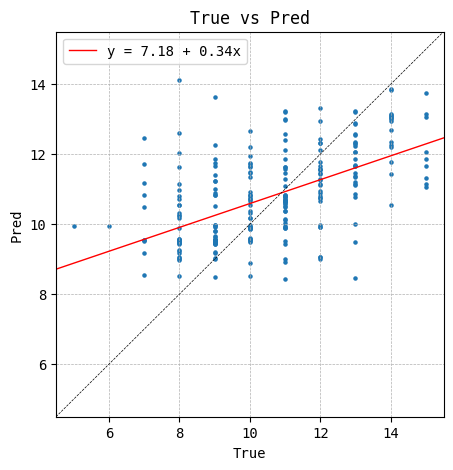

In [170]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(test_label.values, predictions, s=5)
ax.set_xlabel("True")
ax.set_ylabel("Pred")

# Generar valores para la línea de regresión dentro del rango ajustado
x = np.linspace(xmin, xmax, 100)
y = ffit(x)
ax.plot(x, y, color="red", lw=1, label=f"y = {coefs[0]:.2f} + {coefs[1]:.2f}x")

ax.legend()

ax.set_title("True vs Pred")
ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)

# Línea de 45 grados (perfecta predicción)
ax.plot([xmin, xmax], [xmin, xmax], ls="--", lw=0.5, color="black")

ax.grid(ls="--", lw=0.5)

plt.show()

# FIN